In [1]:
%pip install pylatexenc

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator
from qiskit.providers.basic_provider import BasicSimulator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [62]:

# Run this ONCE to save your account permanently

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token="",  # Use your REGENERATED key
    instance="qmlInstance"     # ← exact name from your dashboard
)

backend = service.least_busy(operational=True, simulator=False)
print(f"Connected to: {backend.name}")


qiskit_runtime_service._discover_account:WARNING:2026-03-02 15:03:44,334: Loading account with the given token. A saved account will not be used.


Connected to: ibm_fez


In [33]:
# Load your saved account
# service = QiskitRuntimeService()

# # Find the least busy real quantum computer
# backend = service.least_busy(operational=True, simulator=False)
# print(f"You are connected to: {backend.name}")

# QISKIT

## QUANTUM CIRCUIT WITH X & H GATE

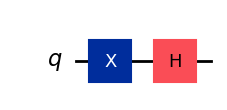

In [34]:
qc=QuantumCircuit(1)
qc.x(0)
qc.h(0)
qc.draw('mpl')

In [35]:
q=Statevector(qc)
q.draw('latex')

<IPython.core.display.Latex object>

In [36]:
q.probabilities()
#gives prob array of measuring 0 and 1

array([0.5, 0.5])

In [37]:
q.sample_counts(100)
#emulate that the experiment runs 100 times

{'0': 48, '1': 52}

In [38]:
U=Operator(qc)
U.draw('latex')
#gives output of unitary operations (in this case, multiplying X with H)


<IPython.core.display.Latex object>

In [39]:
#to confirm, multiply X with H manually
X=Operator.from_label('X')
H=Operator.from_label('H')
U2=H@X
U2.draw('latex')

<IPython.core.display.Latex object>

## 3 qubits

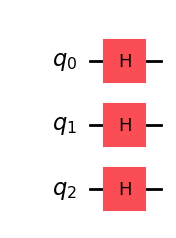

In [40]:
#3 qubit 
qc=QuantumCircuit(3)
qc.h([2,1,0])
qc.draw('mpl')

In [41]:
Statevector(qc).draw('latex')

<IPython.core.display.Latex object>

## ENTANGLED CIRCUITS

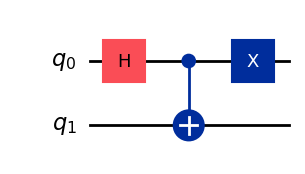

In [42]:
#example circuit
qc2=QuantumCircuit(2)
qc2.h(0)
#control,target
qc2.cx(0,1)
qc2.x(0)
qc2.draw('mpl')

In [43]:
q2=Statevector(qc2)
q2.draw('latex')

<IPython.core.display.Latex object>

In [44]:
counts_sv=q2.sample_counts(100)
print(counts_sv)

{'01': 54, '10': 46}


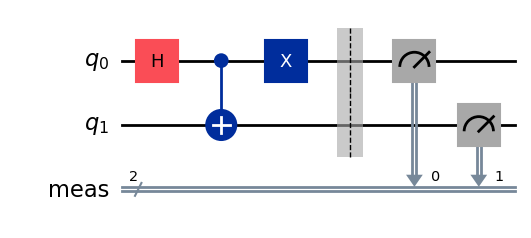

In [45]:
#if number of classical bits are not defined, we can use measure_all. it automatically assigns 
qc2.measure_all()
qc2.draw('mpl')

In [46]:
sim=BasicSimulator()
counts_sim = sim.run(qc2, shots=100).result().get_counts()
print(counts_sim)

{'01': 55, '10': 45}


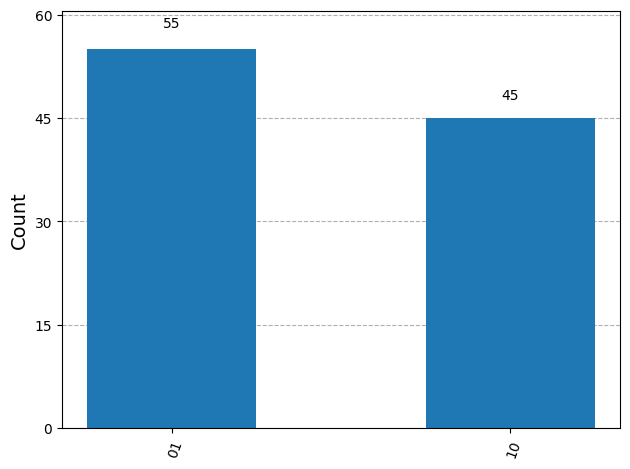

In [47]:
plot_histogram(counts_sim)

## HADAMARD GATE VISUALIZATION (SEPARABLE CIRCUIT)

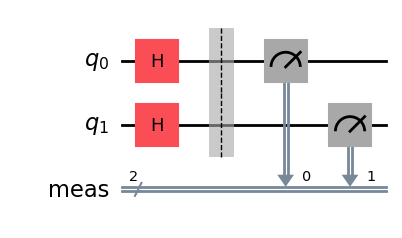

In [48]:
qc3=QuantumCircuit(2)
qc3.h([0,1])
qc3.measure_all()
qc3.draw('mpl')

{'00': 30, '10': 25, '11': 25, '01': 20}


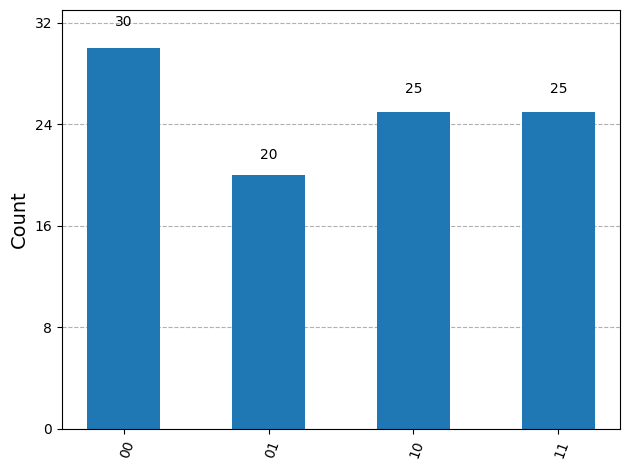

In [49]:
counts_sim = sim.run(qc3, shots=100).result().get_counts()
print(counts_sim)
plot_histogram(counts_sim)
#this shows that qubits are completely uncorrelated, because if q0 is 0, q1 can be either 0 or 1 and vice-versa

# SUMMARY

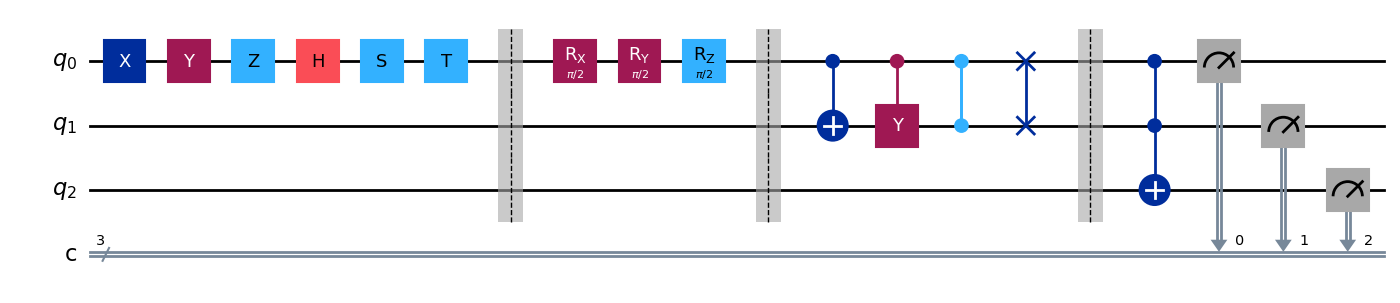

Running on: ibm_fez

--- Measurement Results ---
{'000': 79, '010': 20, '011': 1}


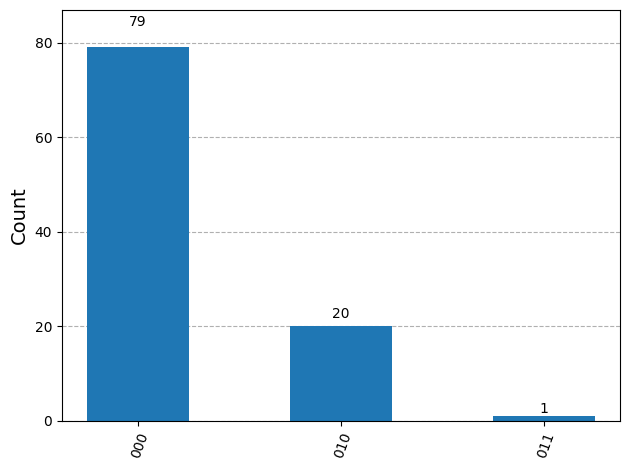

In [64]:
# Create a circuit with 3 Qubits and 3 Classical Bits
# (We need 3 qubits to demonstrate the Toffoli gate)
qc = QuantumCircuit(3, 3)

# SINGLE QUBIT GATES

# Pauli-X (NOT Gate): Flips |0> to |1>
qc.x(0)

# Pauli-Y: Rotate Y + Phase Flip
qc.y(0)

# Pauli-Z: Phase Flip
qc.z(0)

# Hadamard (H): Creates Superposition
qc.h(0)

# S Gate: Phase rotation by 90 degrees (sqrt(Z))
qc.s(0)

# T Gate: Phase rotation by 45 degrees (sqrt(S))
qc.t(0)

# Barrier to visually separate sections in the diagram
qc.barrier()

# ROTATION GATES 

theta = np.pi / 2  # 90 degrees

# Rotation around X-axis
qc.rx(theta, 0)

# Rotation around Y-axis
qc.ry(theta, 0)

# Rotation around Z-axis
qc.rz(theta, 0)

qc.barrier()

# MULTI-QUBIT GATES (Entanglement)

# CNOT (Controlled-X): Flips target(1) if control(0) is |1>
qc.cx(0, 1)

# Controlled-Y: Applies Y to target(1) if control(0) is |1>
qc.cy(0, 1)

# Controlled-Z: Phase flip on target(1) if control(0) is |1>
qc.cz(0, 1)

# SWAP: Swaps the state of qubit 0 and qubit 1
qc.swap(0, 1)

qc.barrier()

# 3-QUBIT GATES

# Toffoli (CCX): Controlled-Controlled-NOT
# If Qubit 0 AND Qubit 1 are |1>, then flip Qubit 2
qc.ccx(0, 1, 2)

# MEASUREMENT

# Measure all 3 qubits and store in classical bits
qc.measure([0, 1, 2], [0, 1, 2])

# EXECUTION AND VISUALIZATION

#Draw the Circuit
display(qc.draw('mpl'))

#Simulate the Result
backend = service.least_busy(operational=True, simulator=False)
print(f"Running on: {backend.name}")

# Transpile circuit for the specific backend
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

# Run using Sampler
sampler = Sampler(backend)
job = sampler.run([isa_circuit], shots=100)
result = job.result()

# Get and plot counts
counts = result[0].data.c.get_counts()
print("\n--- Measurement Results ---")
print(counts)
plot_histogram(counts)

# PENNYLANE

In [51]:
import scipy
import scipy.constants  # Explicitly import constants to fix the AttributeError
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

## Quantum Circuit with X & H Gate (Statevector & Unitary)

--- Circuit Diagram ---


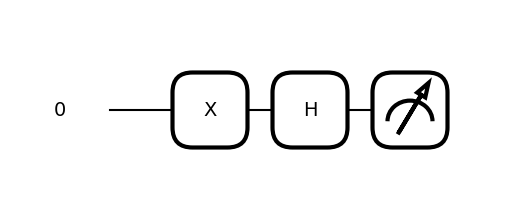

<IPython.core.display.Latex object>


Probabilities: [0.5 0.5]

Unitary Matrix (H @ X):



<IPython.core.display.Latex object>


Manual Unitary (H @ X):



<IPython.core.display.Latex object>

In [52]:
dev1 = qml.device("default.qubit", wires=1)

# @qml.qnode(dev1) tells that The Python function directly below this line is not just regular code. It is a Quantum Circuit that must run on the device named dev1.
@qml.qnode(dev1)

# Define the circuit function
def circuit_xh():
    qml.PauliX(wires=0)
    qml.Hadamard(wires=0)
    return qml.state()  # Equivalent to Statevector(qc)

# Draw the circuit
print("--- Circuit Diagram ---")
qml.draw_mpl(circuit_xh)()
plt.show()

# Get Statevector
state = circuit_xh()
display(Statevector(state).draw('latex'))

# Get Probabilities (equivalent to q.probabilities())
# We can compute this from the state or change the return type of the qnode
@qml.qnode(dev1)
def circuit_probs():
    qml.PauliX(wires=0)
    qml.Hadamard(wires=0)
    return qml.probs(wires=0)

print("\nProbabilities:", circuit_probs())

# Get Unitary Operator (Equivalent to Operator(qc))
# In PennyLane, we use the qml.matrix transform on the quantum function
unitary_matrix = qml.matrix(circuit_xh)()
print("\nUnitary Matrix (H @ X):\n")
display(Operator(unitary_matrix).draw('latex'))

# Manual Verification (H @ X)
# Define gates as matrices and multiply
X_mat = qml.matrix(qml.PauliX(0))
H_mat = qml.matrix(qml.Hadamard(0))
U2 = H_mat @ X_mat  # Matrix multiplication
print("\nManual Unitary (H @ X):\n")
display(Operator(U2).draw('latex'))

## 3 qubits

Hadamard 3 qubits:



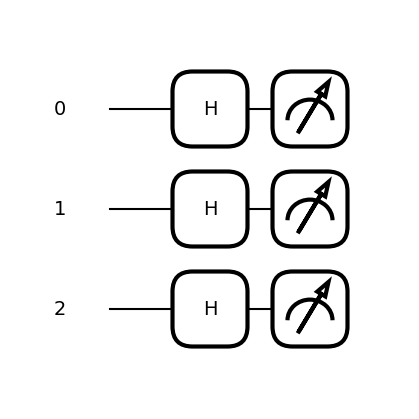

<IPython.core.display.Latex object>

In [53]:
dev2=qml.device("default.qubit",wires=3)

@qml.qnode(dev2)
def circuit_3h():
    for w in [0,1,2]:
        qml.Hadamard(wires=w)
    return qml.state()

print("Hadamard 3 qubits:\n")
qml.draw_mpl(circuit_3h)()
plt.show()
state = circuit_3h()
display(Statevector(state).draw('latex'))


## entangled circuit

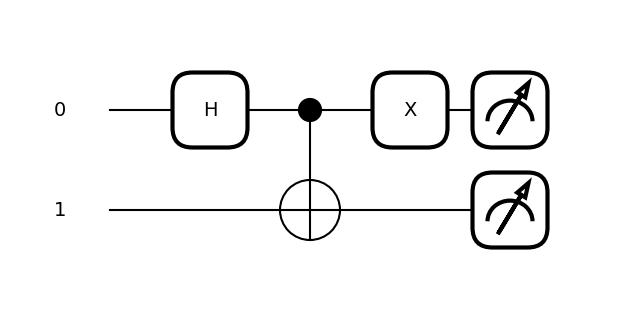


--- Entangled Circuit Counts ---
{'01': 53, '10': 47}


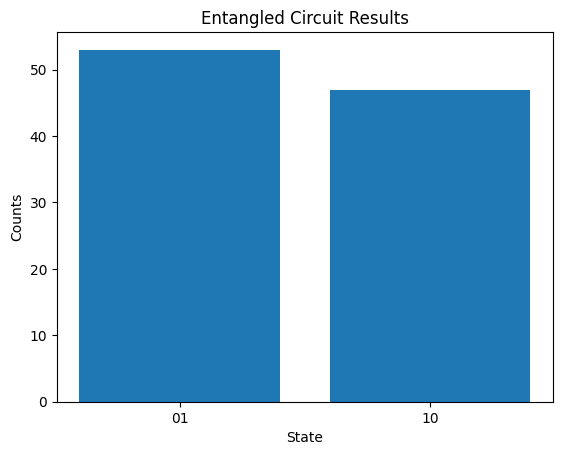

In [54]:
dev_shots = qml.device("default.qubit", wires=2, shots=100)

@qml.qnode(dev_shots)
def circuit_entangled():
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    qml.PauliX(wires=0)
    # Equivalent to measure_all() and get_counts()
    return qml.counts() 

qml.draw_mpl(circuit_entangled)()
plt.show()

print("\n--- Entangled Circuit Counts ---")
counts = circuit_entangled()
print(counts)

# Plotting the histogram
plt.figure()
plt.bar(counts.keys(), counts.values())
plt.title("Entangled Circuit Results")
plt.xlabel("State")
plt.ylabel("Counts")
plt.show()

## HADAMARD GATE VISUALIZATION (SEPARABLE CIRCUIT)

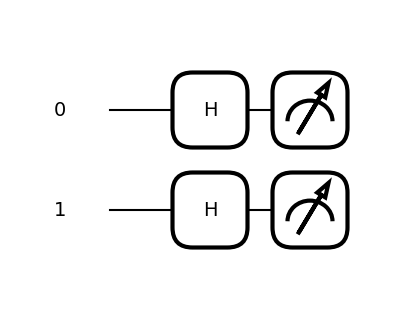


--- Uncorrelated Circuit Counts ---
{'00': 31, '01': 23, '10': 28, '11': 18}


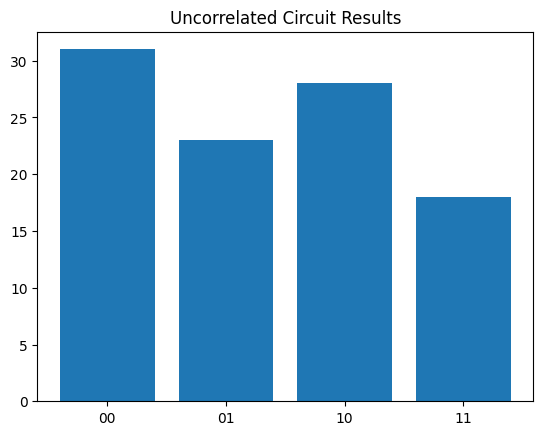

In [55]:
# --- 4. UNCORRELATED CIRCUIT ---

@qml.qnode(dev_shots)
def circuit_uncorrelated():
    qml.Hadamard(wires=0)
    qml.Hadamard(wires=1)
    return qml.counts()

qml.draw_mpl(circuit_uncorrelated)()
plt.show()

print("\n--- Uncorrelated Circuit Counts ---")
counts_uncorr = circuit_uncorrelated()
print(counts_uncorr)

# Plotting
plt.figure()
plt.bar(counts_uncorr.keys(), counts_uncorr.values())
plt.title("Uncorrelated Circuit Results")
plt.show()

## summary


--- Big Circuit Diagram ---


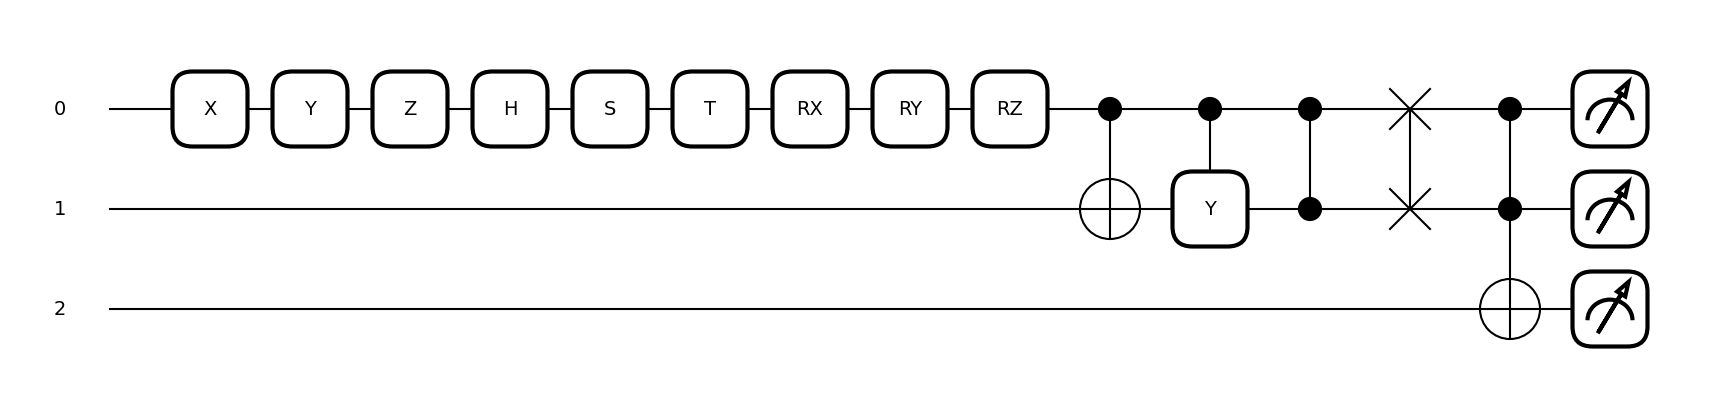


--- Measurement Results (Big Circuit) ---
{'000': 83, '010': 17}


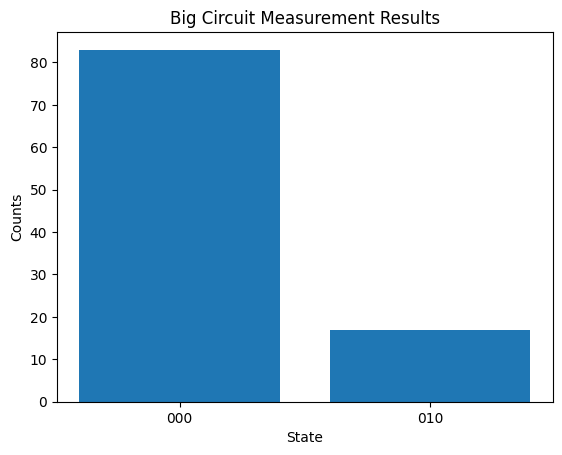

In [56]:
# --- 5. COMPREHENSIVE GATE LIST ---

# Define a 3-wire device with shots
dev_big = qml.device("default.qubit", wires=3, shots=100)

@qml.qnode(dev_big)
def big_circuit():
    # --- SINGLE QUBIT GATES ---
    qml.PauliX(wires=0)      # NOT Gate
    qml.PauliY(wires=0)      # Y Gate
    qml.PauliZ(wires=0)      # Z Gate
    qml.Hadamard(wires=0)    # H Gate
    qml.S(wires=0)           # S Gate (Phase 90)
    qml.T(wires=0)           # T Gate (Phase 45)
    
    # Barrier is visual in Qiskit, usually not needed for logic in PL 
    # but can be mimicked by separating logic blocks.
    
    # --- ROTATION GATES ---
    theta = np.pi / 2
    qml.RX(theta, wires=0)
    qml.RY(theta, wires=0)
    qml.RZ(theta, wires=0)
    
    # --- MULTI-QUBIT GATES ---
    qml.CNOT(wires=[0, 1])   # Control: 0, Target: 1
    qml.CY(wires=[0, 1])     # Controlled-Y
    qml.CZ(wires=[0, 1])     # Controlled-Z
    qml.SWAP(wires=[0, 1])   # Swap 0 and 1
    
    # --- 3-QUBIT GATES ---
    # Toffoli (Control: 0, 1; Target: 2)
    qml.Toffoli(wires=[0, 1, 2])
    
    # --- MEASUREMENT ---
    # Measure all 3 wires and return counts
    return qml.counts(wires=[0, 1, 2])

# Draw the circuit
print("\n--- Big Circuit Diagram ---")
qml.draw_mpl(big_circuit)()
plt.show()

# Execute and get counts
big_counts = big_circuit()
print("\n--- Measurement Results (Big Circuit) ---")
print(big_counts)

# Plot Histogram
plt.figure()
plt.bar(big_counts.keys(), big_counts.values())
plt.title("Big Circuit Measurement Results")
plt.xlabel("State")
plt.ylabel("Counts")
plt.show()

# ALGORITHMS

## Deutsch algorithm

In [57]:
from qiskit import QuantumCircuit
from qiskit.providers.basic_provider import BasicSimulator
import matplotlib.pyplot as plt

def create_oracle(function_type):
    qc_oracle = QuantumCircuit(2)
    if function_type == 'f1':
        qc_oracle.x(1)
    elif function_type == 'fx':
        qc_oracle.cx(0, 1)
    elif function_type == 'fnotx':
        qc_oracle.x(0)
        qc_oracle.cx(0, 1)
        qc_oracle.x(0)
    # f0 (constant 0) needs no gates
    return qc_oracle

def deutsch_algorithm_circuit(oracle_circuit):
    qc = QuantumCircuit(2, 1) # 2 quantum bits, 1 classical bit for measurement
    
    # Initialize second qubit to |1> state, then apply H
    qc.x(1)
    qc.h([0, 1]) # Apply Hadamard to both qubits
    
    # Append the oracle
    qc.compose(oracle_circuit, inplace=True)
    
    # Apply Hadamard to the first qubit
    qc.h(0)
    
    # Measure the first qubit
    qc.measure(0, 0) 
    return qc

# Example run with a balanced function f(x)=x ('fx')
my_oracle = create_oracle('f1')
deutsch_circuit = deutsch_algorithm_circuit(my_oracle)

# Fix: Use 'mpl' drawer and actually display it
print(deutsch_circuit.draw('text'))  # Text version in console
#deutsch_circuit.draw('mpl')  # Matplotlib version
#plt.show()

# --- Updated Execution Block using BasicSimulator ---
# 1. Initialize the BasicSimulator backend
backend = BasicSimulator()

# 2. Run the job
job = backend.run(deutsch_circuit, shots=100)

# 3. Get results
result = job.result()
counts = result.get_counts()
print(f"Measurement counts: {counts}") 

# Interpret the result
measured_bit = list(counts.keys())[0]
if measured_bit == '0':
    print("The function is constant.")
else:
    print("The function is balanced.")

     ┌───┐┌───┐     ┌─┐
q_0: ┤ H ├┤ H ├─────┤M├
     ├───┤├───┤┌───┐└╥┘
q_1: ┤ X ├┤ H ├┤ X ├─╫─
     └───┘└───┘└───┘ ║ 
c: 1/════════════════╩═
                     0 
Measurement counts: {'0': 100}
The function is constant.


Deutsch Algorithm Results

Constant f(x)=0:
  Measurement counts: {0: 100}
  Result: The function is CONSTANT

Circuit diagram for f(x)=0:


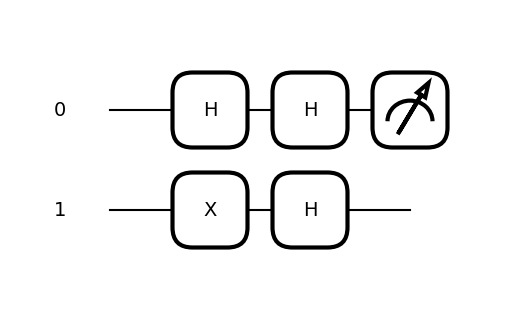


Constant f(x)=1:
  Measurement counts: {0: 100}
  Result: The function is CONSTANT

Circuit diagram for f(x)=1:


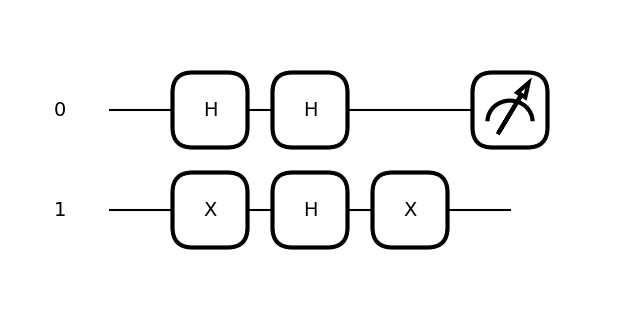


Balanced f(x)=x:
  Measurement counts: {1: 100}
  Result: The function is BALANCED

Circuit diagram for f(x)=x:


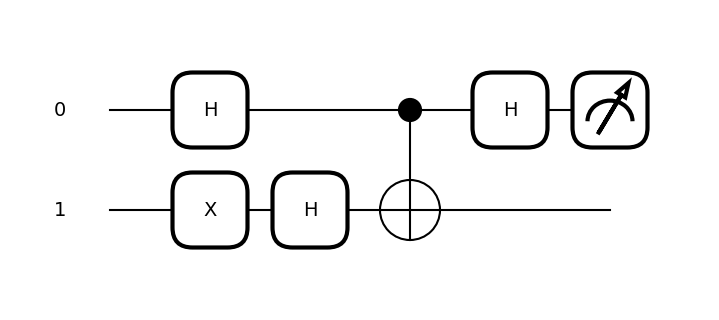


Balanced f(x)=NOT(x):
  Measurement counts: {1: 100}
  Result: The function is BALANCED

Circuit diagram for f(x)=not x:


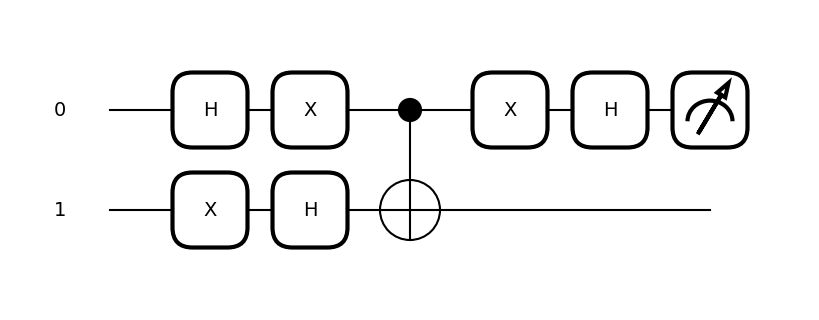

In [58]:
import pennylane as qml
import matplotlib.pyplot as plt
from pennylane import numpy as np

def create_oracle(function_type):
    """Creates oracle for different function types"""
    def oracle():
        if function_type == 'f1':
            # Constant function f(x) = 1
            qml.PauliX(wires=1)
        elif function_type == 'fx':
            # Balanced function f(x) = x
            qml.CNOT(wires=[0, 1])
        elif function_type == 'fnotx':
            # Balanced function f(x) = NOT(x)
            qml.PauliX(wires=0)
            qml.CNOT(wires=[0, 1])
            qml.PauliX(wires=0)
        # f0 (constant 0) needs no gates
    return oracle

def deutsch_algorithm(oracle_func):
    """Implements the Deutsch algorithm circuit"""
    # Initialize second qubit to |1> state
    qml.PauliX(wires=1)
    
    # Apply Hadamard to both qubits
    qml.Hadamard(wires=0)
    qml.Hadamard(wires=1)
    
    # Apply the oracle
    oracle_func()
    
    # Apply Hadamard to the first qubit
    qml.Hadamard(wires=0)
    
    # Measure the first qubit
    return qml.sample(wires=0)

# Test all four function types
function_types = ['f0', 'f1', 'fx', 'fnotx']
function_names = {
    'f0': 'Constant f(x)=0',
    'f1': 'Constant f(x)=1', 
    'fx': 'Balanced f(x)=x',
    'fnotx': 'Balanced f(x)=NOT(x)'
}

print("=" * 60)
print("Deutsch Algorithm Results")
print("=" * 60)

for func_type in function_types:
    # Create device
    dev = qml.device('default.qubit', wires=2, shots=100)
    
    # Get the oracle for this function type
    oracle_func = create_oracle(func_type)
    
    # Create quantum circuit
    @qml.qnode(dev)
    def circuit():
        return deutsch_algorithm(oracle_func)
    
    # Run the circuit
    results = circuit()
    
    # Count measurements
    unique, counts = np.unique(results, return_counts=True)
    measurement_counts = dict(zip(unique, counts))
    
    # Interpret result
    measured_bit = int(unique[np.argmax(counts)])
    if measured_bit == 0:
        interpretation = "CONSTANT"
    else:
        interpretation = "BALANCED"
    
    print(f"\n{function_names[func_type]}:")
    print(f"  Measurement counts: {measurement_counts}")
    print(f"  Result: The function is {interpretation}")
    
    # Draw the circuit (only for the first execution to avoid clutter)
    if func_type == 'fx':
        print("\nCircuit diagram for f(x)=x:")
        fig, ax = qml.draw_mpl(circuit)()
        plt.show()
    if func_type == 'f0':
        print("\nCircuit diagram for f(x)=0:")
        fig, ax = qml.draw_mpl(circuit)()
        plt.show()
    if func_type == 'f1':
        print("\nCircuit diagram for f(x)=1:")
        fig, ax = qml.draw_mpl(circuit)()
        plt.show()
    if func_type == 'fnotx':
        print("\nCircuit diagram for f(x)=not x:")
        fig, ax = qml.draw_mpl(circuit)()
        plt.show()

print("\n" + "=" * 60)

In [59]:
# ============================================================================
# QISKIT IMPLEMENTATIONS
# ============================================================================

from qiskit import QuantumCircuit
from qiskit.providers.basic_provider import BasicSimulator
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------------------------
# DEUTSCH-JOZSA ALGORITHM
# ----------------------------------------------------------------------------

def create_dj_oracle(function_type, n_qubits):
    """Creates oracle for Deutsch-Jozsa algorithm"""
    qc = QuantumCircuit(n_qubits + 1)
    
    if function_type == 'constant_0':
        # Do nothing
        pass
    elif function_type == 'constant_1':
        # Flip output qubit
        qc.x(n_qubits)
    elif function_type == 'balanced':
        # Example balanced function: flip output if first qubit is 1
        qc.cx(0, n_qubits)
    elif function_type == 'balanced_all':
        # Balanced: flip output based on all input qubits
        for i in range(n_qubits):
            qc.cx(i, n_qubits)
    
    return qc

def deutsch_jozsa_circuit(oracle_circuit, n_qubits):
    """Implements Deutsch-Jozsa algorithm"""
    qc = QuantumCircuit(n_qubits + 1, n_qubits)
    
    # Initialize last qubit to |1>
    qc.x(n_qubits)
    
    # Apply Hadamard to all qubits
    qc.h(range(n_qubits + 1))
    
    # Apply oracle
    qc.compose(oracle_circuit, inplace=True)
    
    # Apply Hadamard to input qubits
    qc.h(range(n_qubits))
    
    # Measure input qubits
    qc.measure(range(n_qubits), range(n_qubits))
    
    return qc

# ----------------------------------------------------------------------------
# BERNSTEIN-VAZIRANI ALGORITHM
# ----------------------------------------------------------------------------

def create_bv_oracle(secret_string):
    """Creates oracle for Bernstein-Vazirani algorithm
    secret_string: binary string (e.g., '101')"""
    n_qubits = len(secret_string)
    qc = QuantumCircuit(n_qubits + 1)
    
    # Apply CNOT for each '1' in secret string
    for i, bit in enumerate(reversed(secret_string)):
        if bit == '1':
            qc.cx(i, n_qubits)
    
    return qc

def bernstein_vazirani_circuit(oracle_circuit, n_qubits):
    """Implements Bernstein-Vazirani algorithm"""
    qc = QuantumCircuit(n_qubits + 1, n_qubits)
    
    # Initialize ancilla to |1>
    qc.x(n_qubits)
    
    # Apply Hadamard to all qubits
    qc.h(range(n_qubits + 1))
    
    # Apply oracle
    qc.compose(oracle_circuit, inplace=True)
    
    # Apply Hadamard to input qubits
    qc.h(range(n_qubits))
    
    # Measure input qubits
    qc.measure(range(n_qubits), range(n_qubits))
    
    return qc

# ----------------------------------------------------------------------------
# SIMON'S ALGORITHM
# ----------------------------------------------------------------------------

def create_simon_oracle(secret_string):
    """Creates oracle for Simon's algorithm
    secret_string: binary string representing secret period"""
    n = len(secret_string)
    qc = QuantumCircuit(2 * n)
    
    # Example: Simple oracle that implements f(x) = f(x ⊕ s)
    # Copy x to output register
    for i in range(n):
        qc.cx(i, n + i)
    
    # Apply XOR with secret string
    for i, bit in enumerate(reversed(secret_string)):
        if bit == '1':
            qc.cx(i, n)
    
    return qc

def simon_circuit(oracle_circuit, n_qubits):
    """Implements one iteration of Simon's algorithm"""
    qc = QuantumCircuit(2 * n_qubits, n_qubits)
    
    # Apply Hadamard to input qubits
    qc.h(range(n_qubits))
    
    # Apply oracle
    qc.compose(oracle_circuit, inplace=True)
    
    # Apply Hadamard to input qubits
    qc.h(range(n_qubits))
    
    # Measure input qubits
    qc.measure(range(n_qubits), range(n_qubits))
    
    return qc

# ----------------------------------------------------------------------------
# GROVER'S ALGORITHM
# ----------------------------------------------------------------------------

def create_grover_oracle(marked_states, n_qubits):
    """Creates oracle for Grover's algorithm
    marked_states: list of marked states (e.g., ['11', '00'])"""
    qc = QuantumCircuit(n_qubits)
    
    for marked_state in marked_states:
        # Flip bits that should be 0
        for i, bit in enumerate(reversed(marked_state)):
            if bit == '0':
                qc.x(i)
        
        # Multi-controlled Z gate
        if n_qubits == 2:
            qc.cz(0, 1)
        else:
            # Use multi-controlled Z
            qc.h(n_qubits - 1)
            qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)
            qc.h(n_qubits - 1)
        
        # Flip bits back
        for i, bit in enumerate(reversed(marked_state)):
            if bit == '0':
                qc.x(i)
    
    return qc

def create_diffusion_operator(n_qubits):
    """Creates diffusion operator for Grover's algorithm"""
    qc = QuantumCircuit(n_qubits)
    
    # Apply H gates
    qc.h(range(n_qubits))
    
    # Apply X gates
    qc.x(range(n_qubits))
    
    # Multi-controlled Z
    qc.h(n_qubits - 1)
    qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)
    qc.h(n_qubits - 1)
    
    # Apply X gates
    qc.x(range(n_qubits))
    
    # Apply H gates
    qc.h(range(n_qubits))
    
    return qc

def grover_circuit(oracle_circuit, diffusion_circuit, n_qubits, iterations):
    """Implements Grover's algorithm"""
    qc = QuantumCircuit(n_qubits, n_qubits)
    
    # Initialize with Hadamard
    qc.h(range(n_qubits))
    
    # Apply Grover iterations
    for _ in range(iterations):
        qc.compose(oracle_circuit, inplace=True)
        qc.compose(diffusion_circuit, inplace=True)
    
    # Measure
    qc.measure(range(n_qubits), range(n_qubits))
    
    return qc

# ----------------------------------------------------------------------------
# TEST FUNCTIONS - QISKIT
# ----------------------------------------------------------------------------

def test_deutsch_jozsa_qiskit():
    print("\n" + "="*60)
    print("DEUTSCH-JOZSA ALGORITHM (Qiskit)")
    print("="*60)
    
    n_qubits = 3
    function_types = ['constant_0', 'constant_1', 'balanced', 'balanced_all']
    
    backend = BasicSimulator()
    
    for func_type in function_types:
        oracle = create_dj_oracle(func_type, n_qubits)
        circuit = deutsch_jozsa_circuit(oracle, n_qubits)
        
        job = backend.run(circuit, shots=100)
        result = job.result()
        counts = result.get_counts()
        
        measured_value = list(counts.keys())[0]
        is_constant = all(bit == '0' for bit in measured_value)
        
        print(f"\nFunction type: {func_type}")
        print(f"  Measurement: {measured_value}")
        print(f"  Result: {'CONSTANT' if is_constant else 'BALANCED'}")

def test_bernstein_vazirani_qiskit():
    print("\n" + "="*60)
    print("BERNSTEIN-VAZIRANI ALGORITHM (Qiskit)")
    print("="*60)
    
    secret_strings = ['101', '1101', '110']
    backend = BasicSimulator()
    
    for secret in secret_strings:
        oracle = create_bv_oracle(secret)
        circuit = bernstein_vazirani_circuit(oracle, len(secret))
        
        job = backend.run(circuit, shots=100)
        result = job.result()
        counts = result.get_counts()
        
        measured = list(counts.keys())[0]
        
        print(f"\nSecret string: {secret}")
        print(f"  Measured: {measured}")
        print(f"  Correct: {measured == secret}")

def test_simon_qiskit():
    print("\n" + "="*60)
    print("SIMON'S ALGORITHM (Qiskit)")
    print("="*60)
    
    secret = '11'
    n_qubits = len(secret)
    
    oracle = create_simon_oracle(secret)
    circuit = simon_circuit(oracle, n_qubits)
    
    backend = BasicSimulator()
    job = backend.run(circuit, shots=10)
    result = job.result()
    counts = result.get_counts()
    
    print(f"\nSecret string: {secret}")
    print(f"  Sample measurements: {list(counts.keys())[:5]}")
    print("  (Note: Need multiple runs to solve linear equations)")

def test_grover_qiskit():
    print("\n" + "="*60)
    print("GROVER'S ALGORITHM (Qiskit)")
    print("="*60)
    
    n_qubits = 2
    marked_states = ['11']
    iterations = int(np.pi / 4 * np.sqrt(2**n_qubits))
    
    oracle = create_grover_oracle(marked_states, n_qubits)
    diffusion = create_diffusion_operator(n_qubits)
    circuit = grover_circuit(oracle, diffusion, n_qubits, iterations)
    
    backend = BasicSimulator()
    job = backend.run(circuit, shots=100)
    result = job.result()
    counts = result.get_counts()
    
    print(f"\nMarked state: {marked_states[0]}")
    print(f"  Iterations: {iterations}")
    print(f"  Measurement counts: {counts}")
    most_common = max(counts, key=counts.get)
    print(f"  Most common: {most_common}")


# ============================================================================
# PENNYLANE IMPLEMENTATIONS
# ============================================================================

import pennylane as qml
from pennylane import numpy as pnp

# ----------------------------------------------------------------------------
# DEUTSCH-JOZSA ALGORITHM
# ----------------------------------------------------------------------------

def create_dj_oracle_pl(function_type, n_qubits):
    """Creates oracle for Deutsch-Jozsa algorithm (PennyLane)"""
    def oracle():
        if function_type == 'constant_0':
            pass
        elif function_type == 'constant_1':
            qml.PauliX(wires=n_qubits)
        elif function_type == 'balanced':
            qml.CNOT(wires=[0, n_qubits])
        elif function_type == 'balanced_all':
            for i in range(n_qubits):
                qml.CNOT(wires=[i, n_qubits])
    return oracle

def deutsch_jozsa_algorithm_pl(oracle_func, n_qubits):
    """Implements Deutsch-Jozsa algorithm (PennyLane)"""
    # Initialize last qubit to |1>
    qml.PauliX(wires=n_qubits)
    
    # Apply Hadamard to all qubits
    for i in range(n_qubits + 1):
        qml.Hadamard(wires=i)
    
    # Apply oracle
    oracle_func()
    
    # Apply Hadamard to input qubits
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    
    # Measure input qubits
    return [qml.sample(wires=i) for i in range(n_qubits)]

# ----------------------------------------------------------------------------
# BERNSTEIN-VAZIRANI ALGORITHM
# ----------------------------------------------------------------------------

def create_bv_oracle_pl(secret_string):
    """Creates oracle for Bernstein-Vazirani algorithm (PennyLane)"""
    def oracle():
        n_qubits = len(secret_string)
        for i, bit in enumerate(reversed(secret_string)):
            if bit == '1':
                qml.CNOT(wires=[i, n_qubits])
    return oracle

def bernstein_vazirani_algorithm_pl(oracle_func, n_qubits):
    """Implements Bernstein-Vazirani algorithm (PennyLane)"""
    # Initialize ancilla to |1>
    qml.PauliX(wires=n_qubits)
    
    # Apply Hadamard to all qubits
    for i in range(n_qubits + 1):
        qml.Hadamard(wires=i)
    
    # Apply oracle
    oracle_func()
    
    # Apply Hadamard to input qubits
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    
    # Measure input qubits
    return [qml.sample(wires=i) for i in range(n_qubits)]

# ----------------------------------------------------------------------------
# SIMON'S ALGORITHM
# ----------------------------------------------------------------------------

def create_simon_oracle_pl(secret_string):
    """Creates oracle for Simon's algorithm (PennyLane)"""
    def oracle():
        n = len(secret_string)
        # Copy x to output register
        for i in range(n):
            qml.CNOT(wires=[i, n + i])
        
        # Apply XOR with secret string
        for i, bit in enumerate(reversed(secret_string)):
            if bit == '1':
                qml.CNOT(wires=[i, n])
    return oracle

def simon_algorithm_pl(oracle_func, n_qubits):
    """Implements Simon's algorithm (PennyLane)"""
    # Apply Hadamard to input qubits
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    
    # Apply oracle
    oracle_func()
    
    # Apply Hadamard to input qubits
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    
    # Measure input qubits
    return [qml.sample(wires=i) for i in range(n_qubits)]

# ----------------------------------------------------------------------------
# GROVER'S ALGORITHM
# ----------------------------------------------------------------------------

def create_grover_oracle_pl(marked_states, n_qubits):
    """Creates oracle for Grover's algorithm (PennyLane)"""
    def oracle():
        for marked_state in marked_states:
            # Flip bits that should be 0
            for i, bit in enumerate(reversed(marked_state)):
                if bit == '0':
                    qml.PauliX(wires=i)
            
            # Multi-controlled Z gate
            if n_qubits == 2:
                qml.CZ(wires=[0, 1])
            else:
                qml.Hadamard(wires=n_qubits - 1)
                qml.MultiControlledX(wires=list(range(n_qubits)))
                qml.Hadamard(wires=n_qubits - 1)
            
            # Flip bits back
            for i, bit in enumerate(reversed(marked_state)):
                if bit == '0':
                    qml.PauliX(wires=i)
    return oracle

def create_diffusion_operator_pl(n_qubits):
    """Creates diffusion operator for Grover's algorithm (PennyLane)"""
    def diffusion():
        # Apply H gates
        for i in range(n_qubits):
            qml.Hadamard(wires=i)
        
        # Apply X gates
        for i in range(n_qubits):
            qml.PauliX(wires=i)
        
        # Multi-controlled Z
        qml.Hadamard(wires=n_qubits - 1)
        if n_qubits == 2:
            qml.CNOT(wires=[0, 1])
        else:
            qml.MultiControlledX(wires=list(range(n_qubits)))
        qml.Hadamard(wires=n_qubits - 1)
        
        # Apply X gates
        for i in range(n_qubits):
            qml.PauliX(wires=i)
        
        # Apply H gates
        for i in range(n_qubits):
            qml.Hadamard(wires=i)
    return diffusion

def grover_algorithm_pl(oracle_func, diffusion_func, n_qubits, iterations):
    """Implements Grover's algorithm (PennyLane)"""
    # Initialize with Hadamard
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    
    # Apply Grover iterations
    for _ in range(iterations):
        oracle_func()
        diffusion_func()
    
    # Measure
    return [qml.sample(wires=i) for i in range(n_qubits)]

# ----------------------------------------------------------------------------
# TEST FUNCTIONS - PENNYLANE
# ----------------------------------------------------------------------------

def test_deutsch_jozsa_pennylane():
    print("\n" + "="*60)
    print("DEUTSCH-JOZSA ALGORITHM (PennyLane)")
    print("="*60)
    
    n_qubits = 3
    function_types = ['constant_0', 'constant_1', 'balanced', 'balanced_all']
    
    for func_type in function_types:
        dev = qml.device('default.qubit', wires=n_qubits + 1, shots=100)
        oracle_func = create_dj_oracle_pl(func_type, n_qubits)
        
        @qml.qnode(dev)
        def circuit():
            return deutsch_jozsa_algorithm_pl(oracle_func, n_qubits)
        
        results = circuit()
        
        # Convert results to binary string
        measured = ''.join(str(int(results[i][0])) for i in range(n_qubits))
        is_constant = all(bit == '0' for bit in measured)
        
        print(f"\nFunction type: {func_type}")
        print(f"  Measurement: {measured}")
        print(f"  Result: {'CONSTANT' if is_constant else 'BALANCED'}")

def test_bernstein_vazirani_pennylane():
    print("\n" + "="*60)
    print("BERNSTEIN-VAZIRANI ALGORITHM (PennyLane)")
    print("="*60)
    
    secret_strings = ['101', '1101', '110']
    
    for secret in secret_strings:
        n_qubits = len(secret)
        dev = qml.device('default.qubit', wires=n_qubits + 1, shots=100)
        oracle_func = create_bv_oracle_pl(secret)
        
        @qml.qnode(dev)
        def circuit():
            return bernstein_vazirani_algorithm_pl(oracle_func, n_qubits)
        
        results = circuit()
        measured = ''.join(str(int(results[i][0])) for i in range(n_qubits))
        
        print(f"\nSecret string: {secret}")
        print(f"  Measured: {measured}")
        print(f"  Correct: {measured == secret}")

def test_simon_pennylane():
    print("\n" + "="*60)
    print("SIMON'S ALGORITHM (PennyLane)")
    print("="*60)
    
    secret = '11'
    n_qubits = len(secret)
    dev = qml.device('default.qubit', wires=2 * n_qubits, shots=10)
    oracle_func = create_simon_oracle_pl(secret)
    
    @qml.qnode(dev)
    def circuit():
        return simon_algorithm_pl(oracle_func, n_qubits)
    
    results = circuit()
    measurements = [''.join(str(int(results[i][j])) for i in range(n_qubits)) 
                   for j in range(10)]
    
    print(f"\nSecret string: {secret}")
    print(f"  Sample measurements: {measurements[:5]}")
    print("  (Note: Need multiple runs to solve linear equations)")

def test_grover_pennylane():
    print("\n" + "="*60)
    print("GROVER'S ALGORITHM (PennyLane)")
    print("="*60)
    
    n_qubits = 2
    marked_states = ['11']
    iterations = int(pnp.pi / 4 * pnp.sqrt(2**n_qubits))
    
    dev = qml.device('default.qubit', wires=n_qubits, shots=100)
    oracle_func = create_grover_oracle_pl(marked_states, n_qubits)
    diffusion_func = create_diffusion_operator_pl(n_qubits)
    
    @qml.qnode(dev)
    def circuit():
        return grover_algorithm_pl(oracle_func, diffusion_func, n_qubits, iterations)
    
    results = circuit()
    
    # Count measurements
    measurements = [''.join(str(int(results[i][j])) for i in range(n_qubits)) 
                   for j in range(100)]
    unique, counts = pnp.unique(measurements, return_counts=True)
    measurement_counts = dict(zip(unique, counts))
    
    print(f"\nMarked state: {marked_states[0]}")
    print(f"  Iterations: {iterations}")
    print(f"  Measurement counts: {measurement_counts}")
    most_common = max(measurement_counts, key=measurement_counts.get)
    print(f"  Most common: {most_common}")


# ============================================================================
# RUN ALL TESTS
# ============================================================================

if __name__ == "__main__":
    # Qiskit tests
    test_deutsch_jozsa_qiskit()
    test_bernstein_vazirani_qiskit()
    test_simon_qiskit()
    test_grover_qiskit()
    
    # PennyLane tests
    test_deutsch_jozsa_pennylane()
    test_bernstein_vazirani_pennylane()
    test_simon_pennylane()
    test_grover_pennylane()


DEUTSCH-JOZSA ALGORITHM (Qiskit)

Function type: constant_0
  Measurement: 000
  Result: CONSTANT

Function type: constant_1
  Measurement: 000
  Result: CONSTANT

Function type: balanced
  Measurement: 001
  Result: BALANCED

Function type: balanced_all
  Measurement: 111
  Result: BALANCED

BERNSTEIN-VAZIRANI ALGORITHM (Qiskit)

Secret string: 101
  Measured: 101
  Correct: True

Secret string: 1101
  Measured: 1101
  Correct: True

Secret string: 110
  Measured: 110
  Correct: True

SIMON'S ALGORITHM (Qiskit)

Secret string: 11
  Sample measurements: ['10', '00']
  (Note: Need multiple runs to solve linear equations)

GROVER'S ALGORITHM (Qiskit)

Marked state: 11
  Iterations: 1
  Measurement counts: {'11': 100}
  Most common: 11

DEUTSCH-JOZSA ALGORITHM (PennyLane)

Function type: constant_0
  Measurement: 000
  Result: CONSTANT

Function type: constant_1
  Measurement: 000
  Result: CONSTANT

Function type: balanced
  Measurement: 100
  Result: BALANCED

Function type: balanced_a